In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [15]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [9]:
usuarios_eliminados.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/test_usuarios_eliminados.csv', index=False)

In [ ]:
usuarios_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       29522 non-null  int64  
 1   amount                                   29522 non-null  float64
 2   status                                   29522 non-null  object 
 3   created_at                               29522 non-null  object 
 4   updated_at                               29522 non-null  object 
 5   user_id                                  29522 non-null  float64
 6   moderated_at                             19434 non-null  object 
 7   reimbursement_date                       29522 non-null  object 
 8   cash_request_received_date               22988 non-null  object 
 9   money_back_date                          22750 non-null  object 
 10  transfer_type                            29522

In [ ]:
usuarios_eliminados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2573 entries, 0 to 2572
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       2573 non-null   int64  
 1   amount                                   2573 non-null   float64
 2   status                                   2573 non-null   object 
 3   created_at                               2573 non-null   object 
 4   updated_at                               2573 non-null   object 
 5   moderated_at                             2326 non-null   object 
 6   deleted_account_id                       2573 non-null   float64
 7   reimbursement_date                       2573 non-null   object 
 8   cash_request_received_date               1162 non-null   object 
 9   money_back_date                          1168 non-null   object 
 10  transfer_type                            2573 no

In [ ]:
usuarios_activos["created_at"].min()

Timestamp('2019-11-19 13:57:53.511561')

In [16]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = [
    "created_at", "updated_at", "paid_at", "from_date", "to_date",
    "created_at_fees", "updated_at_fees", "paid_at_fees",
    "cash_request_created_at", "cash_request_updated_at",
    "reimbursement_date", "cash_request_received_date",
    "money_back_date", "send_at", "moderated_at"
]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)




In [17]:
usuarios_activos["cohorte_primer_solicitud"] = usuarios_activos.groupby("user_id")["created_at"].transform("min").dt.to_period("M")
usuarios_eliminados["cohorte_primer_solicitud"] = usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min").dt.to_period("M")

In [18]:
# Crear las columnas necesarias en ambos datasets
for df, user_col in zip([usuarios_activos, usuarios_eliminados], ["user_id", "deleted_account_id"]):
    # Contar total de compras por usuario
    df["total_compras"] = df.groupby(user_col)["id"].transform("count")

    # Sumar el monto total gastado por usuario
    df["monto_total"] = df.groupby(user_col)["amount"].transform("sum")

    # Eliminar duplicados para que cada usuario tenga solo una fila
    df.drop_duplicates(subset=[user_col], inplace=True)

# Verificar que las columnas fueron creadas correctamente
print(usuarios_activos[[ "user_id", "total_compras", "monto_total"]].head())
print(usuarios_eliminados[["deleted_account_id", "total_compras", "monto_total"]].head())


   user_id  total_compras  monto_total
0    804.0              1        100.0
1    231.0             10       1000.0
2    191.0              2        200.0
3    761.0              1         99.0
4   7686.0              1        100.0
   deleted_account_id  total_compras  monto_total
0               309.0              2        200.0
1              2499.0              1        100.0
2               304.0              2        200.0
4                91.0              1        100.0
5               575.0              3        299.0


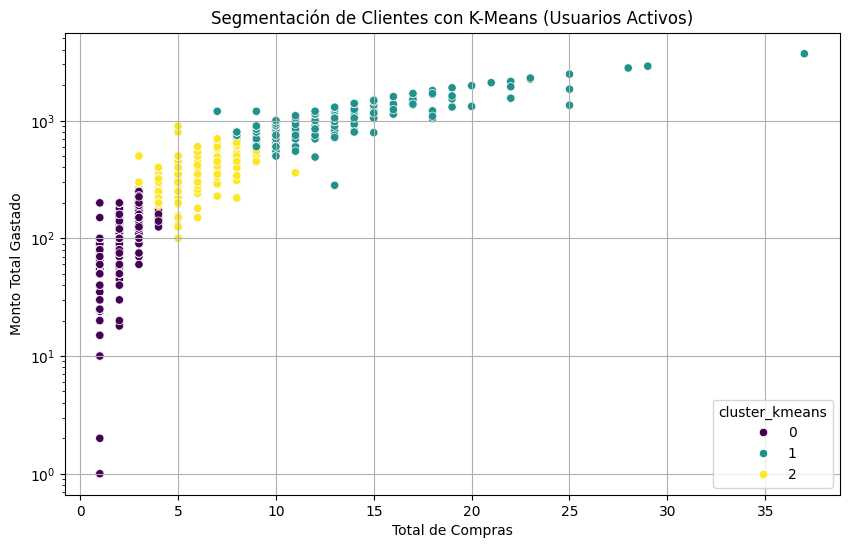

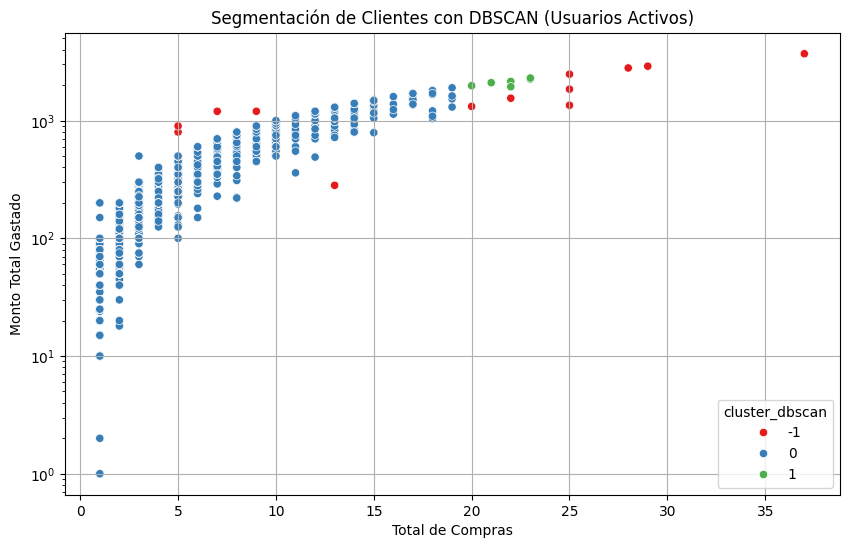

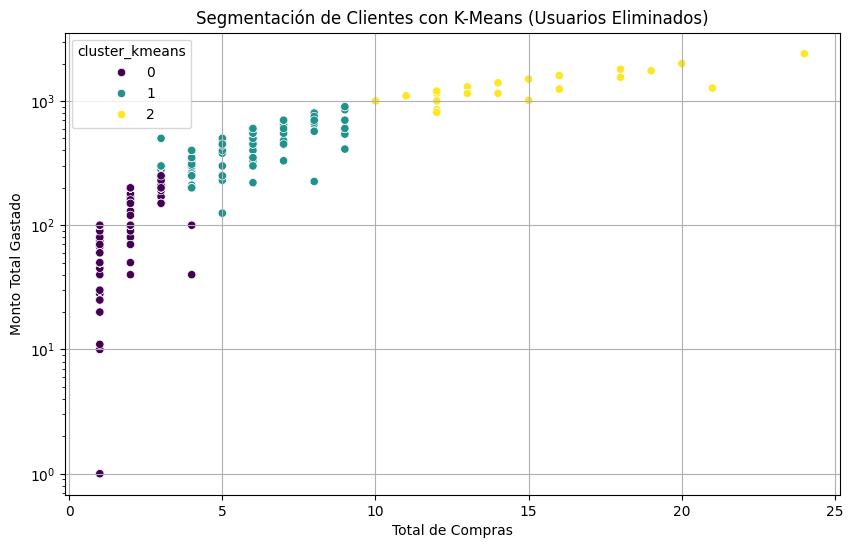

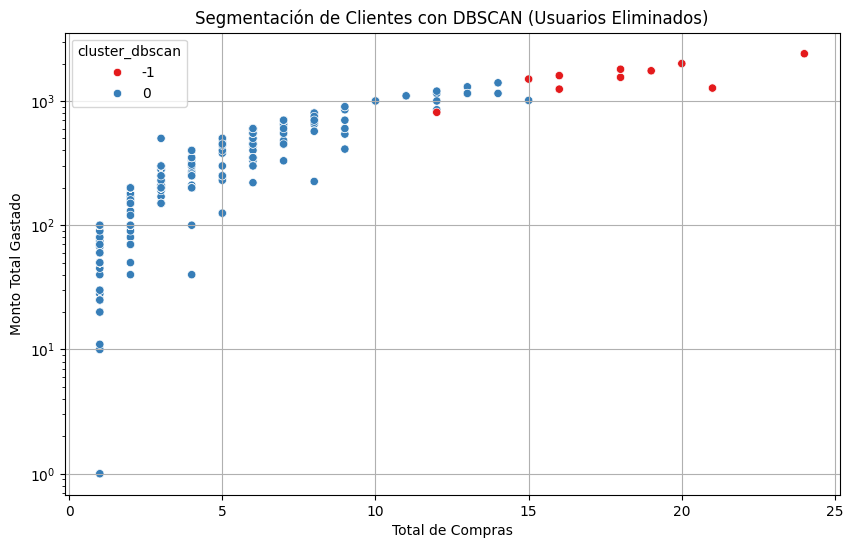

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Función para procesar los datos y aplicar clusterización
def segmentar_clientes(df, titulo):
    # Seleccionar características para la clusterización
    X = df[["total_compras", "monto_total"]].copy()

    # Escalar los datos para mejor normalización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Aplicar K-Means con 3 clusters
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

    # Aplicar DBSCAN
    dbscan = DBSCAN(eps=0.8, min_samples=5)  # Ajustar parámetros según datos
    df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

    # Gráfico K-Means
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df["total_compras"], y=df["monto_total"], hue=df["cluster_kmeans"], palette="viridis")
    plt.xlabel("Total de Compras")
    plt.ylabel("Monto Total Gastado")
    plt.title(f"Segmentación de Clientes con K-Means ({titulo})")
    plt.yscale("log")  # Mejor visualización si hay valores dispersos
    plt.grid(True)
    plt.show()

    # Gráfico DBSCAN
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df["total_compras"], y=df["monto_total"], hue=df["cluster_dbscan"], palette="Set1")
    plt.xlabel("Total de Compras")
    plt.ylabel("Monto Total Gastado")
    plt.title(f"Segmentación de Clientes con DBSCAN ({titulo})")
    plt.yscale("log")
    plt.grid(True)
    plt.show()

# Aplicar segmentación en ambos datasets
segmentar_clientes(usuarios_activos, "Usuarios Activos")
segmentar_clientes(usuarios_eliminados, "Usuarios Eliminados")

Segmentación con K-Means (Usuarios Activos vs. Eliminados)
📊 Patrón observado:

Se identifican tres clusters en ambos grupos:
Cluster 0 (morado): Clientes con bajas compras y bajo gasto.
Cluster 1 (verde/azul): Clientes con más compras y mayor gasto.
Cluster 2 (amarillo): Clientes de alto valor, con más compras y gastos significativamente altos.
🔹 Comparación entre usuarios activos y eliminados:

La distribución de usuarios activos muestra una mayor presencia en los clusters de compras recurrentes (verde/azul).
En cambio, en usuarios eliminados, el cluster de clientes de alto valor (amarillo) sigue presente, pero hay una menor densidad en compras recurrentes.
Esto sugiere que los clientes eliminados tienden a concentrarse en extremos: usuarios de bajo valor o de alto valor.

In [21]:
usuarios_activos.to_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv", index=False)
usuarios_eliminados.to_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv", index=False)


In [24]:

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

In [23]:
!pip install imbalanced-learn


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 📌 2️⃣ Convertir variables numéricas que pueden estar en formato string
cols_numericas = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar las características relevantes
features = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]
X = df_usuarios[features].fillna(0)  # Rellenar posibles valores nulos con 0
y = df_usuarios["status"]

# 📌 6️⃣ Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📌 7️⃣ Separar datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 📌 8️⃣ Entrenar el modelo de Regresión Logística
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 📌 9️⃣ Realizar predicciones en el conjunto de prueba
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

# 📌 🔟 Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Precisión del Modelo: {accuracy:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix)
print("\n🔹 Reporte de Clasificación:")
print(class_report)


🔹 Precisión del Modelo: 0.9045

🔹 Matriz de Confusión:
[[2160    0]
 [ 228    0]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2160
           1       0.00      0.00      0.00       228

    accuracy                           0.90      2388
   macro avg       0.45      0.50      0.47      2388
weighted avg       0.82      0.90      0.86      2388



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas que pueden estar en formato string
cols_numericas = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar las características relevantes
features = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]
X = df_usuarios[features].fillna(0)  # Rellenar posibles valores nulos con 0
y = df_usuarios["status"]

# 📌 6️⃣ Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Ajustamos para que la clase 1 tenga el 50% de la clase 0
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# 📌 9️⃣ Entrenar el modelo de Regresión Logística con los datos balanceados
log_reg_smote = LogisticRegression()
log_reg_smote.fit(X_train, y_train)

# 📌 🔟 Realizar predicciones en el conjunto de prueba
y_pred_smote = log_reg_smote.predict(X_test)
y_pred_prob_smote = log_reg_smote.predict_proba(X_test)[:, 1]

# 📌 Evaluar el modelo después de aplicar SMOTE
accuracy_smote = accuracy_score(y_test, y_pred_smote)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
class_report_smote = classification_report(y_test, y_pred_smote)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Precisión del Modelo después de SMOTE: {accuracy_smote:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix_smote)
print("\n🔹 Reporte de Clasificación:")
print(class_report_smote)


🔹 Precisión del Modelo después de SMOTE: 0.8025

🔹 Matriz de Confusión:
[[1918  242]
 [ 398  682]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      2160
           1       0.74      0.63      0.68      1080

    accuracy                           0.80      3240
   macro avg       0.78      0.76      0.77      3240
weighted avg       0.80      0.80      0.80      3240



In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar variables predictivas (incluyendo nuevas variables)
features_extra = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]
X_extra = df_usuarios[features_extra].fillna(0)
y_extra = df_usuarios["status"]

# 📌 6️⃣ Normalizar variables
scaler_extra = StandardScaler()
X_scaled_extra = scaler_extra.fit_transform(X_extra)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # 50% de la clase mayoritaria
X_resampled_extra, y_resampled_extra = smote.fit_resample(X_scaled_extra, y_extra)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train_extra, X_test_extra, y_train_extra, y_test_extra = train_test_split(
    X_resampled_extra, y_resampled_extra, test_size=0.2, random_state=42, stratify=y_resampled_extra
)

# 📌 9️⃣ Optimización de Hiperparámetros en Regresión Logística
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # Regularización
    "penalty": ["l2"],  # Solo L2 para estabilidad
    "solver": ["liblinear", "lbfgs"]  # Probar diferentes optimizadores
}

log_reg_opt = LogisticRegression()
grid_search = GridSearchCV(log_reg_opt, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_extra, y_train_extra)

# 📌 🔟 Evaluación del Mejor Modelo Encontrado
best_model = grid_search.best_estimator_

# Predicciones
y_pred_opt = best_model.predict(X_test_extra)
y_pred_prob_opt = best_model.predict_proba(X_test_extra)[:, 1]

# 📌 Evaluación del modelo optimizado
accuracy_opt = accuracy_score(y_test_extra, y_pred_opt)
conf_matrix_opt = confusion_matrix(y_test_extra, y_pred_opt)
class_report_opt = classification_report(y_test_extra, y_pred_opt)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"🔹 Precisión del Modelo Optimizado: {accuracy_opt:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix_opt)
print("\n🔹 Reporte de Clasificación:")
print(class_report_opt)


🔹 Mejores Hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
🔹 Precisión del Modelo Optimizado: 0.8022

🔹 Matriz de Confusión:
[[1917  243]
 [ 398  682]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      2160
           1       0.74      0.63      0.68      1080

    accuracy                           0.80      3240
   macro avg       0.78      0.76      0.77      3240
weighted avg       0.80      0.80      0.80      3240



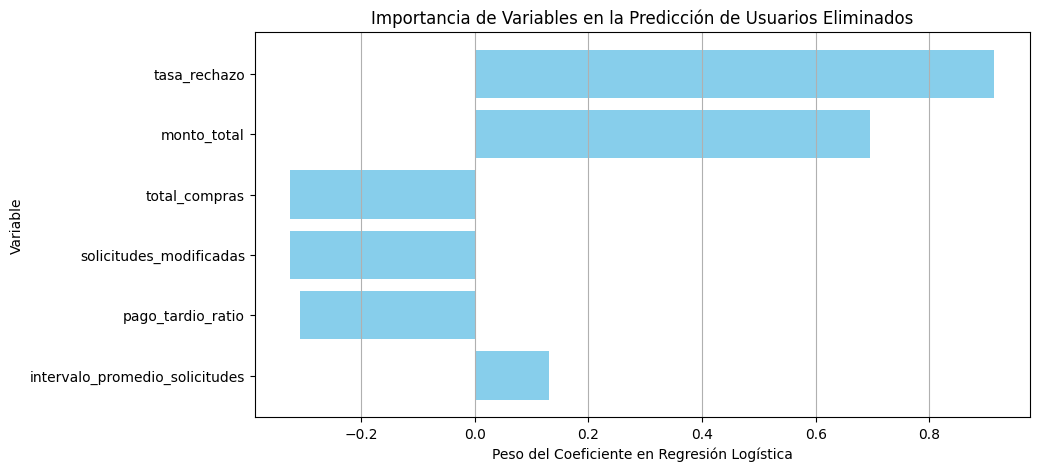

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar variables predictivas
features_extra = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]
X_extra = df_usuarios[features_extra].fillna(0)
y_extra = df_usuarios["status"]

# 📌 6️⃣ Normalizar variables
scaler_extra = StandardScaler()
X_scaled_extra = scaler_extra.fit_transform(X_extra)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled_extra, y_resampled_extra = smote.fit_resample(X_scaled_extra, y_extra)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train_extra, X_test_extra, y_train_extra, y_test_extra = train_test_split(
    X_resampled_extra, y_resampled_extra, test_size=0.2, random_state=42, stratify=y_resampled_extra
)

# 📌 9️⃣ Entrenar el modelo de Regresión Logística con los mejores hiperparámetros
log_reg_opt = LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
log_reg_opt.fit(X_train_extra, y_train_extra)

# 📌 🔟 Obtener coeficientes del modelo optimizado
feature_importance = log_reg_opt.coef_[0]

# 📌 🔹 Asociar coeficientes con nombres de variables
importance_df = pd.DataFrame({"Variable": features_extra, "Importancia": feature_importance})

# 📌 🔹 Ordenar por importancia absoluta
importance_df["Importancia_Abs"] = np.abs(importance_df["Importancia"])
importance_df = importance_df.sort_values(by="Importancia_Abs", ascending=False)

# 📌 📊 Gráfico de importancia de variables
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Variable"], importance_df["Importancia"], color="skyblue")
plt.xlabel("Peso del Coeficiente en Regresión Logística")
plt.ylabel("Variable")
plt.title("Importancia de Variables en la Predicción de Usuarios Eliminados")
plt.gca().invert_yaxis()  # Invertir eje para que la variable más importante esté arriba
plt.grid(axis="x")

# 📌 Mostrar gráfico
plt.show()


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# -----------------------------------------------------------------------------
# 1️⃣ Cargar los datasets
# -----------------------------------------------------------------------------
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# -----------------------------------------------------------------------------
# 2️⃣ Convertir variables numéricas
# -----------------------------------------------------------------------------
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# 3️⃣ Crear la variable objetivo 'status' (0 = activo, 1 = eliminado)
# -----------------------------------------------------------------------------
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# -----------------------------------------------------------------------------
# 4️⃣ Unificar ambos datasets
# -----------------------------------------------------------------------------
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# -----------------------------------------------------------------------------
# 5️⃣ Seleccionar variables predictivas
# -----------------------------------------------------------------------------
features_extra = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

# Puedes optar por imputar valores nulos con la mediana en lugar de 0
X = df_usuarios[features_extra]
X = X.fillna(X.median())
y = df_usuarios["status"]

# -----------------------------------------------------------------------------
# 6️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
#     Esto se hace ANTES del escalado y SMOTE para evitar data leakage.
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------------------------------------
# 7️⃣ Construir un Pipeline que incluya escalado, SMOTE y el modelo
# -----------------------------------------------------------------------------
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),  # SMOTE solo se aplica al conjunto de entrenamiento
    ("classifier", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])

# -----------------------------------------------------------------------------
# 8️⃣ Optimización de Hiperparámetros con GridSearchCV
#     Nota: Se utilizan los nombres de los pasos del pipeline para referenciar los hiperparámetros.
# -----------------------------------------------------------------------------
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]  # lbfgs puede requerir ajustar 'max_iter' en algunos casos
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

# -----------------------------------------------------------------------------
# 9️⃣ Evaluación del Mejor Modelo Encontrado
# -----------------------------------------------------------------------------
best_model = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# -----------------------------------------------------------------------------
# 🔟 Mostrar Resultados
# -----------------------------------------------------------------------------
print("🔹 Mejores Hiperparámetros:", grid_search.best_params_)
print(f"🔹 Precisión del Modelo Optimizado: {accuracy:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix)
print("\n🔹 Reporte de Clasificación:")
print(class_report)
print(f"🔹 ROC AUC: {roc_auc:.4f}")


🔹 Mejores Hiperparámetros: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
🔹 Precisión del Modelo Optimizado: 0.8622

🔹 Matriz de Confusión:
[[1919  241]
 [  88  140]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2160
           1       0.37      0.61      0.46       228

    accuracy                           0.86      2388
   macro avg       0.66      0.75      0.69      2388
weighted avg       0.90      0.86      0.88      2388

🔹 ROC AUC: 0.7917


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# -----------------------------------------------------------------------------
# 1️⃣ Cargar los datasets
# -----------------------------------------------------------------------------
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# -----------------------------------------------------------------------------
# 2️⃣ Convertir variables numéricas
# -----------------------------------------------------------------------------
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# 3️⃣ Crear la variable objetivo 'status' (0 = activo, 1 = eliminado)
# -----------------------------------------------------------------------------
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# -----------------------------------------------------------------------------
# 4️⃣ Unificar ambos datasets
# -----------------------------------------------------------------------------
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# -----------------------------------------------------------------------------
# 5️⃣ Seleccionar variables predictivas y la variable objetivo
# -----------------------------------------------------------------------------
# En este ejemplo, usamos las columnas numéricas
X = df_usuarios[cols_numericas]
# Para la imputación, utilizamos la mediana en lugar de 0, pues puede ser más adecuado
X = X.fillna(X.median())
y = df_usuarios["status"]

# -----------------------------------------------------------------------------
# 6️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
#     Esto se hace antes de aplicar escalado y SMOTE para evitar data leakage.
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------------------------------------
# 7️⃣ Construir un Pipeline que incluya escalado, SMOTE y el modelo de Regresión Logística
# -----------------------------------------------------------------------------
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    # SMOTE solo se aplicará sobre el conjunto de entrenamiento en cada fold de validación
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("classifier", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])

# -----------------------------------------------------------------------------
# 8️⃣ Optimización de Hiperparámetros con GridSearchCV
#     Se utiliza el F1-score para la clase positiva (usuarios eliminados) como métrica.
# -----------------------------------------------------------------------------
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("🔹 Mejores Hiperparámetros:", grid_search.best_params_)

# -----------------------------------------------------------------------------
# 9️⃣ Evaluación del Modelo en el Conjunto de Prueba (umbral por defecto = 0.5)
# -----------------------------------------------------------------------------
best_model = grid_search.best_estimator_

# Predicciones con umbral por defecto
y_pred_default = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

accuracy_default = accuracy_score(y_test, y_pred_default)
roc_auc_default = roc_auc_score(y_test, y_pred_prob)
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
class_report_default = classification_report(y_test, y_pred_default)

print("\n🔹 Evaluación con umbral de decisión por defecto (0.5):")
print(f"Precisión: {accuracy_default:.4f}")
print(f"ROC AUC: {roc_auc_default:.4f}")
print("Matriz de Confusión:")
print(conf_matrix_default)
print("Reporte de Clasificación:")
print(class_report_default)

# -----------------------------------------------------------------------------
# 🔟 Optimización Manual del Umbral de Decisión para Mejorar el F1-score de la Clase 1
# -----------------------------------------------------------------------------
# Se recorre un rango de umbrales para ver cuál maximiza el F1-score en el conjunto de prueba.
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

# Predicciones usando el mejor umbral encontrado
y_pred_best = (y_pred_prob >= best_threshold).astype(int)

accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob)  # La ROC AUC no depende del umbral
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print("\n🔹 Optimización del Umbral de Decisión:")
print(f"Mejor umbral encontrado: {best_threshold:.2f}")
print(f"F1-score con el mejor umbral: {best_f1:.4f}")
print(f"Precisión con el mejor umbral: {accuracy_best:.4f}")
print("Matriz de Confusión con el mejor umbral:")
print(conf_matrix_best)
print("Reporte de Clasificación con el mejor umbral:")
print(class_report_best)


🔹 Mejores Hiperparámetros: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}

🔹 Evaluación con umbral de decisión por defecto (0.5):
Precisión: 0.8622
ROC AUC: 0.7917
Matriz de Confusión:
[[1919  241]
 [  88  140]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2160
           1       0.37      0.61      0.46       228

    accuracy                           0.86      2388
   macro avg       0.66      0.75      0.69      2388
weighted avg       0.90      0.86      0.88      2388


🔹 Optimización del Umbral de Decisión:
Mejor umbral encontrado: 0.51
F1-score con el mejor umbral: 0.4620
Precisión con el mejor umbral: 0.8635
Matriz de Confusión con el mejor umbral:
[[1922  238]
 [  88  140]]
Reporte de Clasificación con el mejor umbral:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2160
           1       0.37      0.61      0.46       228

    

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# -----------------------------------------------------------------------------
# 1️⃣ Cargar los datasets
# -----------------------------------------------------------------------------
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# -----------------------------------------------------------------------------
# 2️⃣ Convertir variables numéricas
# -----------------------------------------------------------------------------
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# 3️⃣ Crear la variable objetivo 'status' (0 = activo, 1 = eliminado)
# -----------------------------------------------------------------------------
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# -----------------------------------------------------------------------------
# 4️⃣ Unificar ambos datasets
# -----------------------------------------------------------------------------
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# -----------------------------------------------------------------------------
# 5️⃣ Seleccionar variables predictivas y la variable objetivo
# -----------------------------------------------------------------------------
X = df_usuarios[cols_numericas]
# Imputar valores nulos utilizando la mediana de cada columna
X = X.fillna(X.median())
y = df_usuarios["status"]

# -----------------------------------------------------------------------------
# 6️⃣ Separar los datos en entrenamiento y prueba (80% - 20%)
#     Esta separación se hace antes del preprocesamiento para evitar data leakage.
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------------------------------------------------------
# 7️⃣ Construir un Pipeline con escalado, SMOTE y el modelo de Regresión Logística
#     Se incorpora 'class_weight="balanced"' para dar mayor peso a la clase minoritaria.
# -----------------------------------------------------------------------------
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("classifier", LogisticRegression(penalty="l2", solver="lbfgs",
                                        class_weight="balanced", random_state=42))
])

# -----------------------------------------------------------------------------
# 8️⃣ Optimización de Hiperparámetros con GridSearchCV
#     Se utiliza el F1-score (para la clase positiva) como métrica.
# -----------------------------------------------------------------------------
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("🔹 Mejores Hiperparámetros:", grid_search.best_params_)

# -----------------------------------------------------------------------------
# 9️⃣ Evaluación del Modelo en el Conjunto de Prueba (umbral de decisión 0.5)
# -----------------------------------------------------------------------------
best_model = grid_search.best_estimator_

# Predicciones con el umbral por defecto (0.5)
y_pred_default = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

accuracy_default = accuracy_score(y_test, y_pred_default)
roc_auc_default = roc_auc_score(y_test, y_pred_prob)
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
class_report_default = classification_report(y_test, y_pred_default)

print("\n🔹 Evaluación con umbral de decisión por defecto (0.5):")
print(f"Precisión: {accuracy_default:.4f}")
print(f"ROC AUC: {roc_auc_default:.4f}")
print("Matriz de Confusión:")
print(conf_matrix_default)
print("Reporte de Clasificación:")
print(class_report_default)

# -----------------------------------------------------------------------------
# 🔟 Optimización Manual del Umbral de Decisión para Mejorar el F1-score
# -----------------------------------------------------------------------------
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

# Predicciones usando el mejor umbral encontrado
y_pred_best = (y_pred_prob >= best_threshold).astype(int)
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob)  # La ROC AUC es independiente del umbral
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print("\n🔹 Optimización del Umbral de Decisión:")
print(f"Mejor umbral encontrado: {best_threshold:.2f}")
print(f"F1-score con el mejor umbral: {best_f1:.4f}")
print(f"Precisión con el mejor umbral: {accuracy_best:.4f}")
print("Matriz de Confusión con el mejor umbral:")
print(conf_matrix_best)
print("Reporte de Clasificación con el mejor umbral:")
print(class_report_best)


🔹 Mejores Hiperparámetros: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}

🔹 Evaluación con umbral de decisión por defecto (0.5):
Precisión: 0.8300
ROC AUC: 0.7928
Matriz de Confusión:
[[1830  330]
 [  76  152]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2160
           1       0.32      0.67      0.43       228

    accuracy                           0.83      2388
   macro avg       0.64      0.76      0.66      2388
weighted avg       0.90      0.83      0.86      2388


🔹 Optimización del Umbral de Decisión:
Mejor umbral encontrado: 0.74
F1-score con el mejor umbral: 0.4626
Precisión con el mejor umbral: 0.8647
Matriz de Confusión con el mejor umbral:
[[1926  234]
 [  89  139]]
Reporte de Clasificación con el mejor umbral:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2160
           1       0.37      0.61      0.46       228

    acc

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# -----------------------------------------------------------------------------
# 1️⃣ Cargar los datasets
# -----------------------------------------------------------------------------
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# -----------------------------------------------------------------------------
# 2️⃣ Convertir variables numéricas
# -----------------------------------------------------------------------------
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# 3️⃣ Crear la variable objetivo 'status' (0 = activo, 1 = eliminado)
# -----------------------------------------------------------------------------
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# -----------------------------------------------------------------------------
# 4️⃣ Unificar ambos datasets
# -----------------------------------------------------------------------------
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# -----------------------------------------------------------------------------
# 5️⃣ Seleccionar variables predictivas y la variable objetivo
# -----------------------------------------------------------------------------
X = df_usuarios[cols_numericas]
# Imputar valores nulos utilizando la mediana de cada columna
X = X.fillna(X.median())
y = df_usuarios["status"]

# -----------------------------------------------------------------------------
# 6️⃣ Separar los datos en entrenamiento y prueba (80% - 20%)
#     Esta separación se hace antes del preprocesamiento para evitar data leakage.
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------------------------------------------------------
# 7️⃣ Construir un Pipeline con escalado, SMOTE y Random Forest
#     Se utiliza class_weight='balanced' para que el modelo preste mayor atención
#     a la clase minoritaria.
# -----------------------------------------------------------------------------
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

# -----------------------------------------------------------------------------
# 8️⃣ Optimización de Hiperparámetros con GridSearchCV
#     Se utiliza el F1-score (enfocado en la clase positiva) como métrica.
# -----------------------------------------------------------------------------
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("🔹 Mejores Hiperparámetros:", grid_search.best_params_)

# -----------------------------------------------------------------------------
# 9️⃣ Evaluación del Modelo en el Conjunto de Prueba (umbral de decisión 0.5)
# -----------------------------------------------------------------------------
best_model = grid_search.best_estimator_

# Predicciones con el umbral por defecto (0.5)
y_pred_default = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

accuracy_default = accuracy_score(y_test, y_pred_default)
roc_auc_default = roc_auc_score(y_test, y_pred_prob)
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
class_report_default = classification_report(y_test, y_pred_default)

print("\n🔹 Evaluación con umbral de decisión por defecto (0.5):")
print(f"Precisión: {accuracy_default:.4f}")
print(f"ROC AUC: {roc_auc_default:.4f}")
print("Matriz de Confusión:")
print(conf_matrix_default)
print("Reporte de Clasificación:")
print(class_report_default)

# -----------------------------------------------------------------------------
# 🔟 Optimización Manual del Umbral de Decisión para Mejorar el F1-score
# -----------------------------------------------------------------------------
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

# Predicciones usando el mejor umbral encontrado
y_pred_best = (y_pred_prob >= best_threshold).astype(int)
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob)  # La ROC AUC es independiente del umbral
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print("\n🔹 Optimización del Umbral de Decisión:")
print(f"Mejor umbral encontrado: {best_threshold:.2f}")
print(f"F1-score con el mejor umbral: {best_f1:.4f}")
print(f"Precisión con el mejor umbral: {accuracy_best:.4f}")
print("Matriz de Confusión con el mejor umbral:")
print(conf_matrix_best)
print("Reporte de Clasificación con el mejor umbral:")
print(class_report_best)


🔹 Mejores Hiperparámetros: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

🔹 Evaluación con umbral de decisión por defecto (0.5):
Precisión: 0.8534
ROC AUC: 0.7784
Matriz de Confusión:
[[1903  257]
 [  93  135]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      2160
           1       0.34      0.59      0.44       228

    accuracy                           0.85      2388
   macro avg       0.65      0.74      0.68      2388
weighted avg       0.90      0.85      0.87      2388


🔹 Optimización del Umbral de Decisión:
Mejor umbral encontrado: 0.53
F1-score con el mejor umbral: 0.4415
Precisión con el mejor umbral: 0.8580
Matriz de Confusión con el mejor umbral:
[[1915  245]
 [  94  134]]
Reporte de Clasificación con el mejor umbral:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2160
           1   

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.base import BaseEstimator, ClassifierMixin

# -----------------------------------------------------------------------------
# 0️⃣ Crear un wrapper para XGBoost que solucione el problema de __sklearn_tags__
# -----------------------------------------------------------------------------
class XGBClassifierWrapper(xgb.XGBClassifier, BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def __sklearn_tags__(self):
        # Se retornan algunos tags mínimos para que scikit-learn reconozca este estimador como clasificador
        return {"non_deterministic": True, "requires_y": True}

# -----------------------------------------------------------------------------
# 1️⃣ Cargar los datasets
# -----------------------------------------------------------------------------
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# -----------------------------------------------------------------------------
# 2️⃣ Convertir variables numéricas
# -----------------------------------------------------------------------------
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# 3️⃣ Crear la variable objetivo 'status' (0 = activo, 1 = eliminado)
# -----------------------------------------------------------------------------
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# -----------------------------------------------------------------------------
# 4️⃣ Unificar ambos datasets
# -----------------------------------------------------------------------------
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# -----------------------------------------------------------------------------
# 5️⃣ Seleccionar variables predictivas y la variable objetivo
# -----------------------------------------------------------------------------
X = df_usuarios[cols_numericas]
# Imputar valores nulos utilizando la mediana de cada columna
X = X.fillna(X.median())
y = df_usuarios["status"]

# -----------------------------------------------------------------------------
# 6️⃣ Separar los datos en entrenamiento y prueba (80% - 20%)
#     Esta separación se hace antes del preprocesamiento para evitar data leakage.
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------------------------------------------------------
# 7️⃣ Construir un Pipeline con escalado, SMOTE y el clasificador XGBoost (wrapper)
# -----------------------------------------------------------------------------
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("classifier", XGBClassifierWrapper(eval_metric='logloss', random_state=42))
])

# -----------------------------------------------------------------------------
# 8️⃣ Optimización de Hiperparámetros con GridSearchCV
#     Se optimiza el F1-score para la clase positiva (usuarios eliminados).
# -----------------------------------------------------------------------------
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 6, 10],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    # Ajuste de scale_pos_weight para compensar el desbalance
    "classifier__scale_pos_weight": [np.sum(y_train == 0) / np.sum(y_train == 1)]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("🔹 Mejores Hiperparámetros:", grid_search.best_params_)

# -----------------------------------------------------------------------------
# 9️⃣ Evaluación del Modelo en el Conjunto de Prueba (umbral de decisión = 0.5)
# -----------------------------------------------------------------------------
best_model = grid_search.best_estimator_

# Predicciones con el umbral por defecto (0.5)
y_pred_default = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

accuracy_default = accuracy_score(y_test, y_pred_default)
roc_auc_default = roc_auc_score(y_test, y_pred_prob)
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
class_report_default = classification_report(y_test, y_pred_default)

print("\n🔹 Evaluación con umbral de decisión por defecto (0.5):")
print(f"Precisión: {accuracy_default:.4f}")
print(f"ROC AUC: {roc_auc_default:.4f}")
print("Matriz de Confusión:")
print(conf_matrix_default)
print("Reporte de Clasificación:")
print(class_report_default)

# -----------------------------------------------------------------------------
# 🔟 Optimización Manual del Umbral de Decisión para Mejorar el F1-score
# -----------------------------------------------------------------------------
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

# Predicciones usando el mejor umbral encontrado
y_pred_best = (y_pred_prob >= best_threshold).astype(int)
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob)  # La ROC AUC es independiente del umbral
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print("\n🔹 Optimización del Umbral de Decisión:")
print(f"Mejor umbral encontrado: {best_threshold:.2f}")
print(f"F1-score con el mejor umbral: {best_f1:.4f}")
print(f"Precisión con el mejor umbral: {accuracy_best:.4f}")
print("Matriz de Confusión con el mejor umbral:")
print(conf_matrix_best)
print("Reporte de Clasificación con el mejor umbral:")
print(class_report_best)


🔹 Mejores Hiperparámetros: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 9.461117196056955}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'